# Coalescence with ML — report notebook

A short, runnable tour of the thesis: coalescing random walks on a ring, and a
DQN agent that learns to **suppress** or **facilitate** their coalescence relative to the `1/sqrt(pi t)` baseline.

The headline figures are generated by `make_figures.py`; this notebook shows the
machinery live on a couple of trained agents.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from coalescence import make_env, DQNAgent
from coalescence.evaluate import rollout_density, random_density, theoretical_asymptote

# dark styling to match the project figures
BG, TEXT, MUTED, TEAL, VIOLET, FAINT = '#0f1420','#e6edf6','#9aa7b8','#2dd4bf','#a78bfa','#64748b'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,
    'text.color':TEXT,'axes.labelcolor':TEXT,'axes.edgecolor':MUTED,'xtick.color':MUTED,
    'ytick.color':MUTED,'axes.titlecolor':TEXT,'axes.grid':True,'grid.color':'#1c2433',
    'legend.frameon':False})
np.random.seed(0); torch.manual_seed(0)

## The environment

`N` particles on a ring of `L` sites. Each step a particle hops; landing on an
occupied site merges the two. Here is the lattice coalescing under a random walk
— each row is one sweep, bright cells are particles.

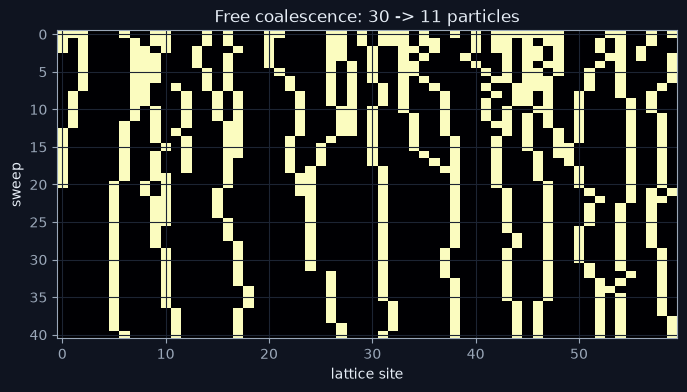

In [2]:
env = make_env('global_particle', length=60, n_particles=30, rng=0)
history = [env.lattice.copy()]
for _ in range(40):
    for _ in range(env.particles):
        env.step(np.random.randint(0, env.action_dim))
    history.append(env.lattice.copy())

fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(np.array(history), aspect='auto', cmap='magma', interpolation='nearest')
ax.set_xlabel('lattice site'); ax.set_ylabel('sweep')
ax.set_title(f'Free coalescence: {env.n_particles} -> {env.particles} particles')
plt.show()

## Suppressing coalescence

A trained 'choose particle' agent on `L = 50`. Watch the density stay well above
both the random agent and the `1/sqrt(pi t)` baseline — it is actively keeping
the particles apart.

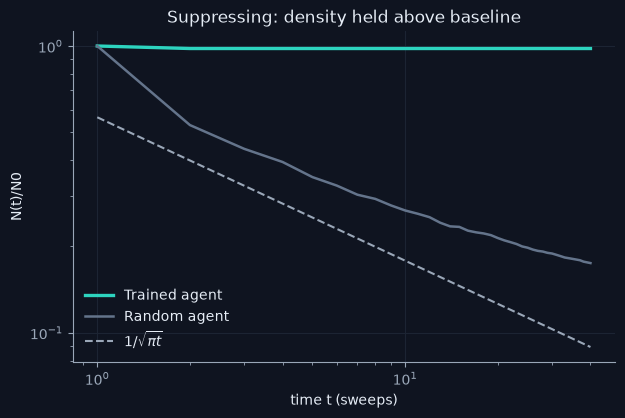

In [3]:
def density_plot(variant, L, N, model, facilitating, n_sweeps=40, n_runs=20):
    agent = DQNAgent(make_env(variant, L, N, facilitating=facilitating, rng=0))
    agent.load(model)
    agent_curve = np.mean([rollout_density(agent, make_env(variant, L, N, facilitating=facilitating, rng=r), n_sweeps) for r in range(n_runs)], axis=0)
    rand_curve  = np.mean([random_density(make_env(variant, L, N, rng=r), n_sweeps) for r in range(n_runs)], axis=0)
    t = np.arange(1, n_sweeps + 1)
    fig, ax = plt.subplots(figsize=(7, 4.3))
    ax.plot(t, agent_curve, color=TEAL, lw=2.4, label='Trained agent')
    ax.plot(t, rand_curve, color=FAINT, lw=1.8, label='Random agent')
    ax.plot(t, theoretical_asymptote(n_sweeps), color=MUTED, ls='--', lw=1.5, label=r'$1/\sqrt{\pi t}$')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('time t (sweeps)'); ax.set_ylabel('N(t)/N0'); ax.legend()
    for s in ('top','right'): ax.spines[s].set_visible(False)
    return ax

ax = density_plot('global_particle', 50, 50, 'models/global_particle_suppress_L50.pth', facilitating=False)
ax.set_title('Suppressing: density held above baseline'); plt.show()

## Facilitating coalescence

Same machinery, opposite reward. The agent now drives particles together, so the
density drops *below* the baseline.

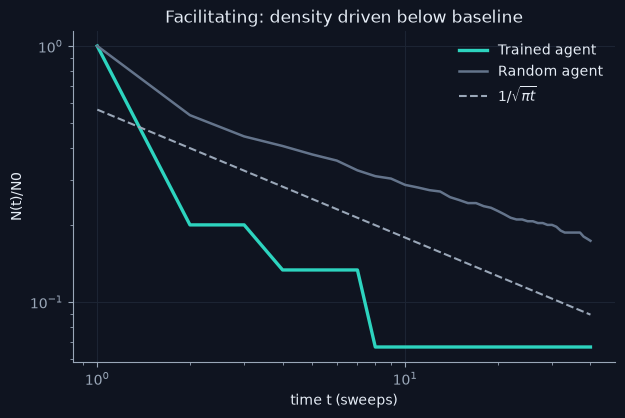

In [4]:
ax = density_plot('global_particle_action', 15, 15, 'models/global_particle_action_facilitate_L15.pth', facilitating=True)
ax.set_title('Facilitating: density driven below baseline'); plt.show()

## Where to go next

- `make_figures.py` regenerates the full figure set (both goals, all three
  formulations, the hyperparameter study) from the saved `results/`.
- `configs/` holds one YAML per experiment; `python -m coalescence.train --config <...>`
  retrains from scratch.
- `src/coalescence/envs.py` is where the three control formulations live.